# Exploring COCO annotations for pork package inspection

**MMA3001 engineering assignment — exploratory data analysis**

This notebook examines the training images and COCO annotations before developing a pork package inspection model. It explores the JSON structure, counts images and labels, links annotations to images, and compares annotated and unannotated examples.

The purpose is to assess a provisional image-level rule: **no annotations → PASS; one or more defect annotations → FAIL**. 

## 1. Setup and data loading

The following cell imports tools for reading JSON, handling file paths, opening and drawing on images (Pillow), and plotting images (Matplotlib). The `%pip` command installs the image and plotting packages in the notebook environment. Run cells in order so variables are available when needed.

The relative paths assume the working directory is the project's notebooks folder, with training files in `../data/raw/train/`. The next two cells locate the COCO annotation file and load it into `coco_data`, a Python dictionary. Images are stored separately and opened later.

In [1]:
#Import libraries
import json
from pathlib import Path
%pip install pillow matplotlib
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from pathlib import Path

Note: you may need to restart the kernel to use updated packages.


In [2]:
annotation_path = Path("../data/raw/train/_annotations.coco.json")

In [3]:
with open(annotation_path, "r") as file:
    coco_data = json.load(file)

## 2. Explore the COCO structure

COCO is a common format for object-detection labels. The next cell lists the top-level keys present in this file. The main collections used here are:

| Collection | Contents | Link to other records |
| --- | --- | --- |
| `images` | Image IDs, filenames and dimensions. | Image `id` is referenced by annotations. |
| `annotations` | Individual labelled regions, including bounding boxes. | `image_id` links to an image; `category_id` links to a category. |
| `categories` | Category IDs and readable class names. | Category `id` gives an annotation its class meaning. |

IDs are identifiers, not necessarily list positions. One image can contain several annotations.

In [4]:
print(coco_data.keys())

dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])


### Inspect the categories

Print the category records to identify the supplied defect names and IDs. The exact meaning of each class should be checked against the dataset documentation before using it as an inspection criterion.

In [5]:
for category in coco_data["categories"]:
    print(category)

{'id': 0, 'name': 'packaging-error', 'supercategory': 'none'}
{'id': 1, 'name': 'loose-meat', 'supercategory': 'packaging-error'}
{'id': 2, 'name': 'packaging-error', 'supercategory': 'packaging-error'}
{'id': 3, 'name': 'twisted-meat', 'supercategory': 'packaging-error'}
{'id': 4, 'name': 'unsealed', 'supercategory': 'packaging-error'}
{'id': 5, 'name': 'wrinkle', 'supercategory': 'packaging-error'}


### Count images and labelled regions

Count the image records and annotation records in this split. An annotation represents a labelled region, so the annotation count is not the number of defective packages.

In [6]:
print("Number of images:", len(coco_data["images"]))
print("Number of annotations:", len(coco_data["annotations"]))

Number of images: 3349
Number of annotations: 2923


### Inspect example records

The next two cells print the first image record and first annotation record to show their fields. Matching list positions do not establish a relationship: annotations must be connected to images through `image_id` and `id`.

In [7]:
print(coco_data["images"][0])

{'id': 0, 'license': 1, 'file_name': 'frame_with_red_8214_jpg.rf.5acda82172bcf022bd7f017eb084474d.jpg', 'height': 540, 'width': 720, 'date_captured': '2026-08-11T05:59:42+00:00', 'extra': {'name': 'frame_with_red_8214.jpg'}}


In [8]:
print(coco_data["annotations"][0])

{'id': 1, 'image_id': 0, 'category_id': 2, 'bbox': [562.22, 387.78, 35.56, 28.89], 'iscrowd': 0, 'area': 1027.328, 'segmentation': []}


## 3. Count images with and without annotations

Collect annotation `image_id` values in a set, which keeps each ID only once. This counts images with at least one recorded annotation, even where an image has multiple regions. Subtracting that count from the total gives the number without annotations, assuming every annotation refers to a valid image.

At this point, unannotated means only that no annotation is recorded. It could indicate no target defect, but incomplete labelling is also possible.

In [9]:
annotated_image_ids = set()

for annotation in coco_data["annotations"]:
    annotated_image_ids.add(annotation["image_id"])

print("Images with annotations:", len(annotated_image_ids))
print("Images without annotations:", len(coco_data["images"]) - len(annotated_image_ids))

Images with annotations: 2665
Images without annotations: 684


## 4. Connect labels to one image

Create `category_names`, a lookup from category IDs to readable names. This allows each box to display a class name rather than a number.

In [10]:
category_names = {}

for category in coco_data["categories"]:
    category_names[category["id"]] = category["name"]

print(category_names)

{0: 'packaging-error', 1: 'loose-meat', 2: 'packaging-error', 3: 'twisted-meat', 4: 'unsealed', 5: 'wrinkle'}


### Select an image and collect its labels

The next two cells select the first image record and find every annotation whose `image_id` matches that image's `id`. This prevents labels from other images being drawn on the selected image.

In [11]:
image_record = coco_data["images"][0]

print(image_record)

{'id': 0, 'license': 1, 'file_name': 'frame_with_red_8214_jpg.rf.5acda82172bcf022bd7f017eb084474d.jpg', 'height': 540, 'width': 720, 'date_captured': '2026-08-11T05:59:42+00:00', 'extra': {'name': 'frame_with_red_8214.jpg'}}


In [12]:
image_annotations = []

for annotation in coco_data["annotations"]:
    if annotation["image_id"] == image_record["id"]:
        image_annotations.append(annotation)

print(image_annotations)

[{'id': 1, 'image_id': 0, 'category_id': 2, 'bbox': [562.22, 387.78, 35.56, 28.89], 'iscrowd': 0, 'area': 1027.328, 'segmentation': []}]


### Draw bounding boxes

Open the image in RGB and draw each matching region and class name. COCO boxes use `[x, y, width, height]`, with `(x, y)` at the top-left corner in pixel coordinates. Pillow needs two rectangle corners, so the code calculates `x2 = x + width` and `y2 = y + height`.

These overlays show the dataset labels, not model predictions. They help check the record matching and interpretation of coordinates.

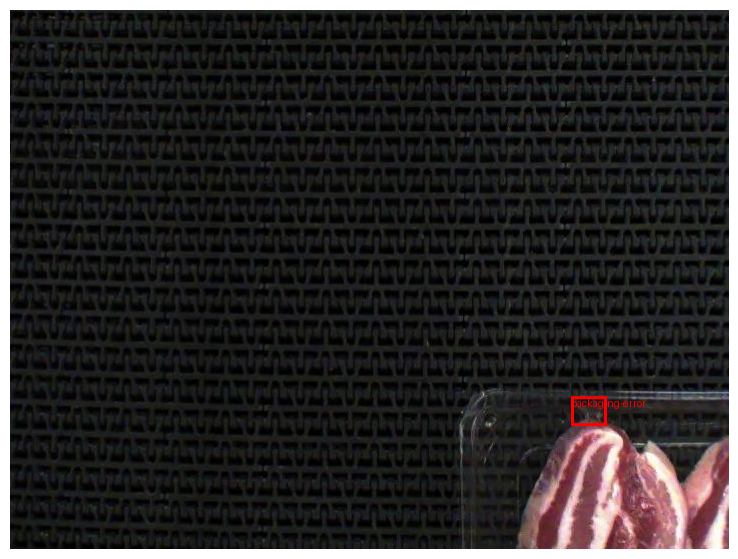

In [13]:
image_path = Path("../data/raw/train") / image_record["file_name"]

image = Image.open(image_path).convert("RGB")
draw = ImageDraw.Draw(image)

for annotation in image_annotations:
    x, y, width, height = annotation["bbox"]

    x2 = x + width
    y2 = y + height

    draw.rectangle([x, y, x2, y2], outline="red", width=3)

    label = category_names[annotation["category_id"]]

    draw.text((x, y), label, fill="red")

plt.figure(figsize=(10, 7))
plt.imshow(image)
plt.axis("off")
plt.show()

## 5. Separate images for comparison

Build `annotated_images` and `unannotated_images` by testing whether each image ID is in the set created earlier. The following cell prints one example record from each group. Using `[0]` assumes both groups contain at least one image.

In [14]:
annotated_images = []
unannotated_images = []

for image_record in coco_data["images"]:
    if image_record["id"] in annotated_image_ids:
        annotated_images.append(image_record)
    else:
        unannotated_images.append(image_record)

In [15]:
print("Annotated example:")
print(annotated_images[0])

print("\nUnannotated example:")
print(unannotated_images[0])

Annotated example:
{'id': 0, 'license': 1, 'file_name': 'frame_with_red_8214_jpg.rf.5acda82172bcf022bd7f017eb084474d.jpg', 'height': 540, 'width': 720, 'date_captured': '2026-08-11T05:59:42+00:00', 'extra': {'name': 'frame_with_red_8214.jpg'}}

Unannotated example:
{'id': 3, 'license': 1, 'file_name': 'frame_with_red_2737_jpg.rf.8af748cd8904c67c7a01876277a66f85.jpg', 'height': 540, 'width': 720, 'date_captured': '2026-08-11T05:59:42+00:00', 'extra': {'name': 'frame_with_red_2737.jpg'}}


## 6. Visually inspect annotated examples

During the initial review, look for visible packaging issues such as open edges, apparent seal irregularities, tears or punctures, material near the sealing surface, and product extending into the seal area. Unusual package shape may also be worth recording, although its interpretation depends on the packaging method.

These observations help compare visible features with dataset labels. Photographs alone cannot confirm seal performance, contamination or microbiological safety.

The next cell displays the first five annotated images without boxes. Inspecting these raw images first allows an initial judgement before labels direct attention to specific regions. The title “Annotated” identifies the group; overlays are not drawn in this block.

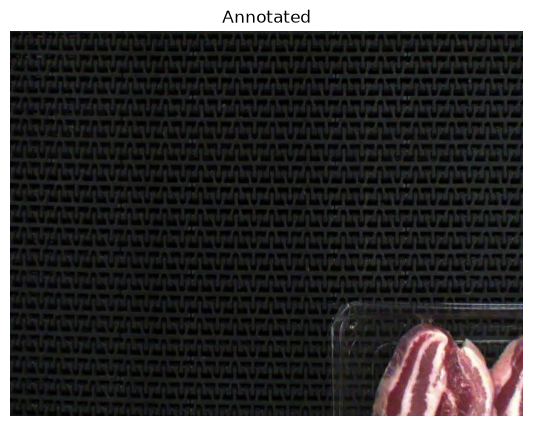

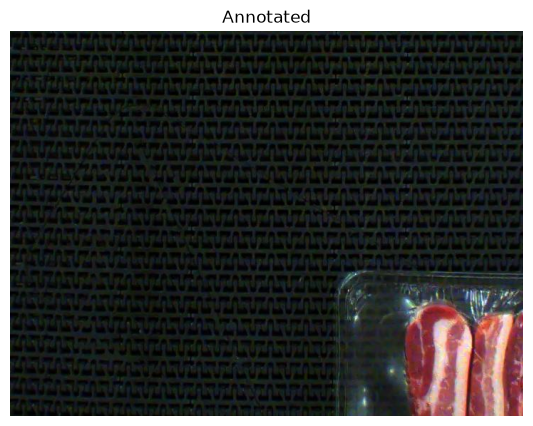

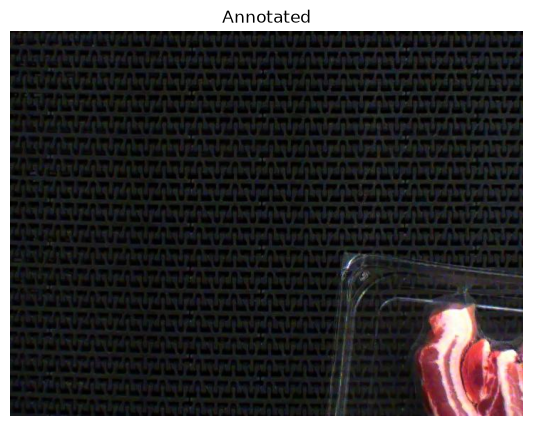

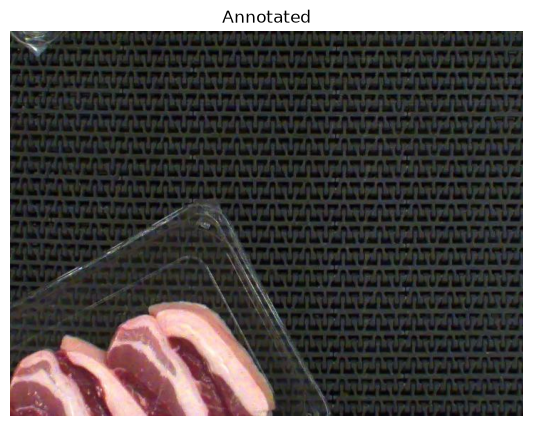

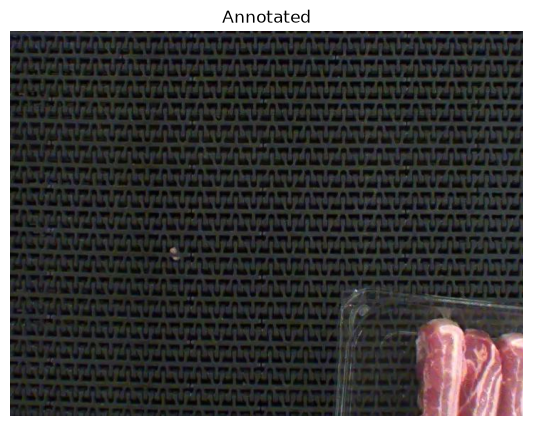

In [16]:
for image_record in annotated_images[:5]:
    image_path = Path("../data/raw/train") / image_record["file_name"]
    image = Image.open(image_path)

    plt.figure(figsize=(8, 5))
    plt.imshow(image)
    plt.title("Annotated")
    plt.axis("off")
    plt.show()

### Compare visual estimates with the recorded annotations

Display the same five images with their matching boxes and class names. Compare these labels with the defects noticed in the raw images. Agreement supports the interpretation of the labels; discrepancies should be recorded and investigated. The first five images are not a random or comprehensive sample.

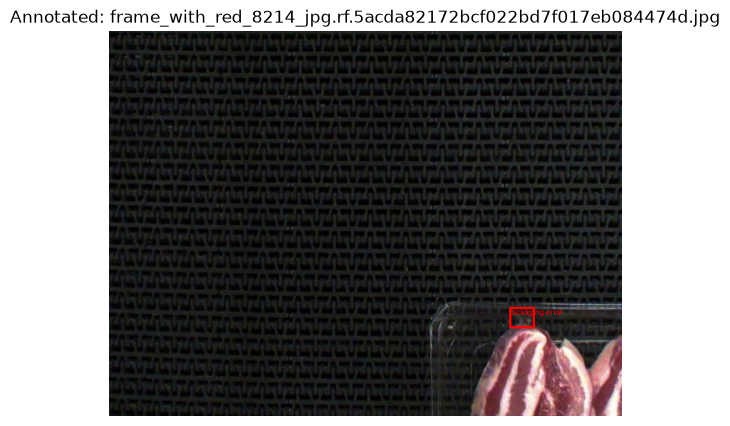

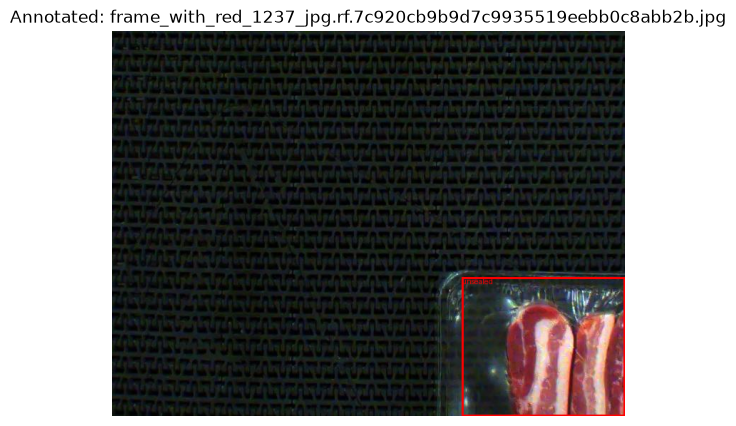

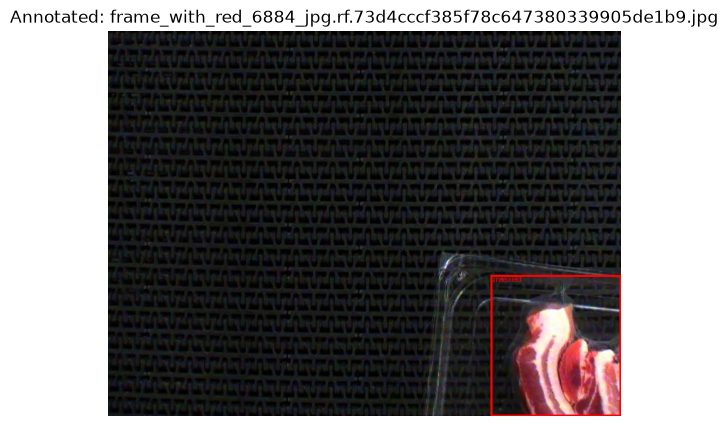

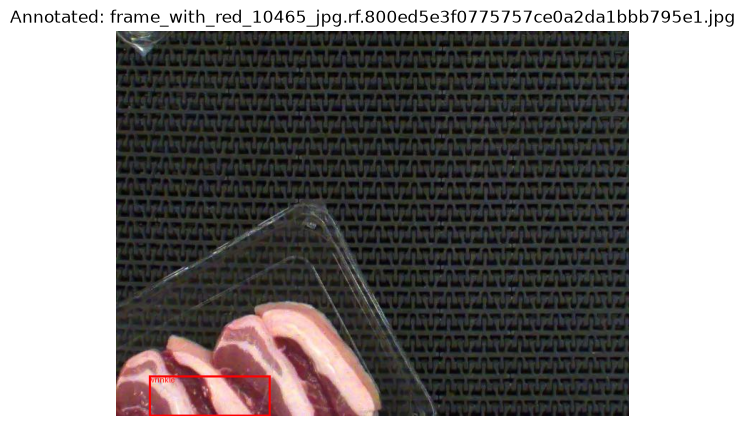

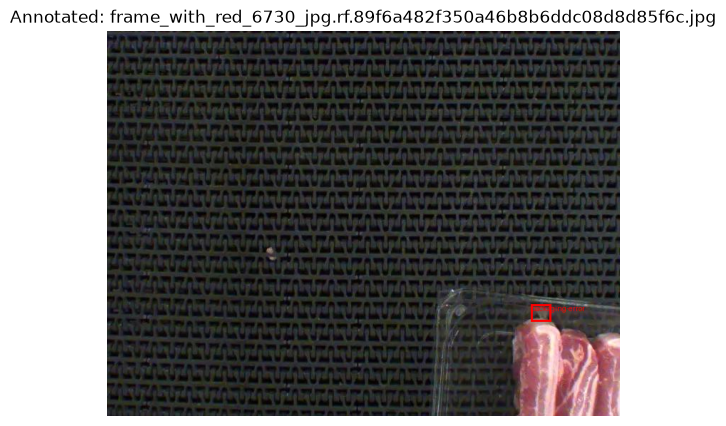

In [17]:
for image_record in annotated_images[:5]:
    image_path = Path("../data/raw/train") / image_record["file_name"]
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)

    # Find all annotations belonging to this image
    image_annotations = []

    for annotation in coco_data["annotations"]:
        if annotation["image_id"] == image_record["id"]:
            image_annotations.append(annotation)

    # Draw each bounding box and class label
    for annotation in image_annotations:
        x, y, width, height = annotation["bbox"]

        x2 = x + width
        y2 = y + height

        draw.rectangle(
            [x, y, x2, y2],
            outline="red",
            width=3
        )

        label = category_names[annotation["category_id"]]

        draw.text(
            (x, y),
            label,
            fill="red"
        )

    # Display image
    plt.figure(figsize=(8, 5))
    plt.imshow(image)
    plt.title(f"Annotated: {image_record['file_name']}")
    plt.axis("off")
    plt.show()

## 7. Visually inspect unannotated examples

Inspect the first five images with no recorded annotations for similar visible issues. This tests whether missing annotations plausibly correspond to acceptable packages under the dataset's criteria. Visible defects would challenge the proposed rule. A small sample without obvious defects cannot establish that all unannotated images are defect-free.

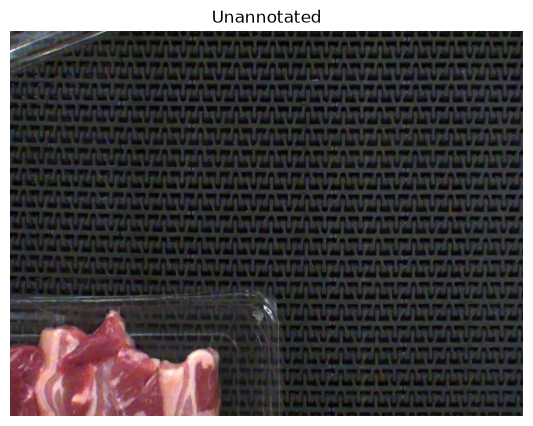

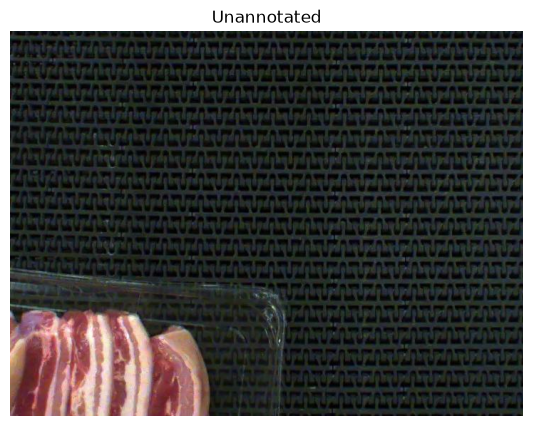

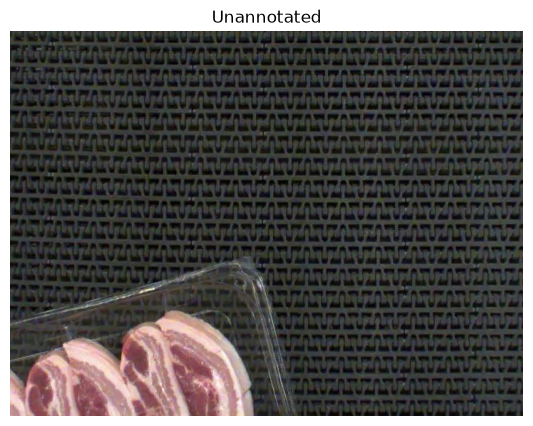

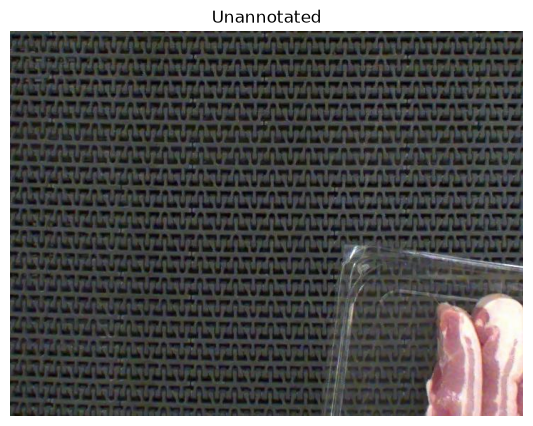

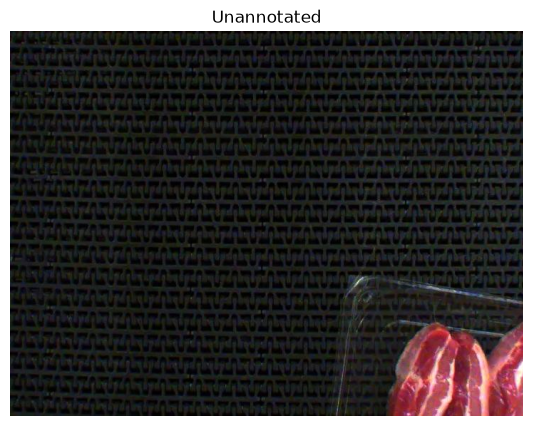

In [18]:
for image_record in unannotated_images[:5]:
    image_path = Path("../data/raw/train") / image_record["file_name"]
    image = Image.open(image_path)

    #Display image
    plt.figure(figsize=(8, 5))
    plt.imshow(image)
    plt.title("Unannotated")
    plt.axis("off")
    plt.show()

## 8. Initial observations and limitations

In the examples reviewed so far, the annotated images appeared to contain the stated defects, while the unannotated examples did not show obvious defects. This is a preliminary observation about the inspected examples, not a verified finding for the full dataset.

The first five images from each group may not represent all packaging conditions or classes. Review a broader selection and confirm whether the dataset creator intended unannotated images to represent no target defects rather than missing labels.

### Inspection quality and food safety

A visible wrinkle or a broad `packaging-error` label does not by itself establish whether a package is safe or unsafe. Its significance depends on the category definition and whether the packaging's protective function is affected. Distinguishing cosmetic issues from defects affecting integrity requires clearer criteria and suitable evidence beyond these images.

For this assignment stage, the proposed target is conformity with the dataset's defect labels. The available annotations should not be presented as verified safe/unsafe labels.

## 9. Provisional PASS/FAIL inspection assumption

| Recorded defect annotations | Provisional image label |
| --- | --- |
| None | PASS |
| One or more | FAIL |

FAIL means the dataset records at least one target defect. PASS means no target defect is recorded, **assuming annotation coverage is complete and unannotated images are intended as negative examples**. Neither label determines food safety.

This rule treats all annotated defect categories equally, including wrinkles and packaging errors. Its suitability remains subject to checking class definitions and annotation completeness. The existing code separates and inspects the groups; it does not yet generate a final PASS/FAIL label table.

Before training, confirm this assumption, document ambiguous examples, and consider how the balance of the two groups could affect evaluation. Any later change to which categories count as FAIL needs an explicit justification.

AI ACKNOWLEDGEMENT

ChatGPT Astra 6 and ChatGPT Sol 5.6 were used to create documentation, as well as write segments of code. All code has been independently verified by me.